##### Import Libraries

In [3]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)

In [4]:
print("Tensorflow version: ", tf.__version__)
print("Num GPUs Available: ",len(tf.config.list_physical_devices('GPU')))

Tensorflow version:  2.21.0
Num GPUs Available:  0


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Random seed set to: ",SEED)

Random seed set to:  42


In [9]:
DATASET_DIR=Path("RealWaste")
class_names=sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])
NUM_CLASSES=len(class_names)
print("No. of classes: ",len(class_names))
print("Classes: ")
for i, class_name in enumerate(class_names):
    print(class_name)

No. of classes:  9
Classes: 
Cardboard
Food Organics
Glass
Metal
Miscellaneous Trash
Paper
Plastic
Textile Trash
Vegetation


In [16]:
class_counts = {}

for class_name in class_names:
    class_dir=DATASET_DIR/class_name
    count=sum(1 for file in class_dir.iterdir())
    class_counts[class_name]=count
class_counts_df=pd.DataFrame(list(class_counts.items()),columns=["Class","Number of Images"])
class_counts_df

,Class,Number of Images
0,Cardboard,461
1,Food Organics,411
2,Glass,420
3,Metal,790
4,Miscellaneous Trash,495
5,Paper,500
6,Plastic,921
7,Textile Trash,318
8,Vegetation,436


In [22]:
TOTAL_IMAGES=class_counts_df["Number of Images"].sum()

##### Data Preprocessing

In [25]:
image_paths=[]
labels=[]
for label, class_name in enumerate(class_names):
    class_dir=DATASET_DIR/class_name
    for file in class_dir.iterdir():
        image_paths.append(str(file))
        labels.append(label)

image_paths=np.array(image_paths)
labels=np.array(labels)

print("Total images:",len(image_paths))


Total images: 4752


In [27]:
# data spliting
X_train, X_temp, y_train, y_temp = train_test_split(image_paths,labels,test_size=0.30,stratify=labels,random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=SEED)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 3326
Validation images: 713
Testing images: 713


In [28]:
# Tensorflow input
IMG_SIZE=(64,64)
BATCH_SIZE=32

def load_image(path,label):
    image=tf.io.read_file(path)
    image=tf.image.decode_image(image,channels=3,expand_animations=False)
    image=tf.image.resize(image,IMG_SIZE)
    image=tf.cast(image,tf.float32)/255.0
    return image,label

In [30]:
train_ds=tf.data.Dataset.from_tensor_slices((X_train,y_train))
val_ds=tf.data.Dataset.from_tensor_slices((X_val,y_val))
test_ds=tf.data.Dataset.from_tensor_slices((X_test,y_test))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#### Model A - Standard CNN

In [49]:
# Build model A
def build_model_A():
    return models.Sequential([
    layers.Input(shape=(64,64,3)),

    layers.Conv2D(16,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [50]:
model_A.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,133 (3.28 MB)

 Trainable params: 286,377 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 572,756 (2.18 MB)

#### Model B - Lightweight CNN

In [51]:
# Build model B
def build_model_B():
    return models.Sequential([
    layers.Input(shape=(64,64,3)),

    layers.SeparableConv2D(16,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.SeparableConv2D(32,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.SeparableConv2D(64,(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(32, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [59]:
model_B=build_model_B()
model_B.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d_9              │ (None, 64, 64, 16)     │            91 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_10             │ (None, 32, 32, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_11             │ (None, 16, 16, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,556 (21.70 KB)

 Trainable params: 5,556 (21.70 KB)

 Non-trainable params: 0 (0.00 B)

####  Optimizer Selection & Tuning

In [53]:
# Compile model A with Adam
model_A=build_model_A()

model_A.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_A_adam = model_A.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


c:\Users\shala\Desktop\Assignment 3 - PR\EN3150_Assignment03_CNN-1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.2865 - loss: 1.9181 - val_accuracy: 0.3801 - val_loss: 1.6182
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4233 - loss: 1.5620 - val_accuracy: 0.4446 - val_loss: 1.4634
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.5045 - loss: 1.3651 - val_accuracy: 0.4811 - val_loss: 1.4243
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5463 - loss: 1.2764 - val_accuracy: 0.5638 - val_loss: 1.2569
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5926 - loss: 1.1142 - val_accuracy: 0.5835 - val_loss: 1.2314
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6401 - loss: 1.0122 - val_accuracy: 0.5568 - val_loss: 1.2617
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6627 - loss: 0.9502 - val_accuracy: 0.5905 - val_loss: 1.1227
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7105 - loss: 0.8216 - val_accuracy: 0.61

In [55]:
# Standard SGD
model_A_sgd=build_model_A()

model_A_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_A_sgd = model_A_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


c:\Users\shala\Desktop\Assignment 3 - PR\EN3150_Assignment03_CNN-1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.1915 - loss: 2.1427 - val_accuracy: 0.1725 - val_loss: 2.1321
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.1996 - loss: 2.1179 - val_accuracy: 0.1753 - val_loss: 2.1066
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.2189 - loss: 2.0813 - val_accuracy: 0.2412 - val_loss: 2.0576
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.2535 - loss: 2.0225 - val_accuracy: 0.1950 - val_loss: 2.0884
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.2790 - loss: 1.9588 - val_accuracy: 0.3366 - val_loss: 1.9102
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.3370 - loss: 1.8455 - val_accuracy: 0.3773 - val_loss: 1.7769
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3752 - loss: 1.7343 - val_accuracy: 0.3815 - val_loss: 1.6914
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4035 - loss: 1.6661 - val_accuracy: 0.415

In [56]:
model_A_momentum=build_model_A()

model_A_momentum.compile(
    optimizer=SGD(learning_rate=0.001,momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_A_momentum = model_A_momentum.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


c:\Users\shala\Desktop\Assignment 3 - PR\EN3150_Assignment03_CNN-1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.1855 - loss: 2.1525 - val_accuracy: 0.1935 - val_loss: 2.1425
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.1984 - loss: 2.1323 - val_accuracy: 0.1935 - val_loss: 2.1273
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.2066 - loss: 2.1151 - val_accuracy: 0.2090 - val_loss: 2.0995
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.2288 - loss: 2.0774 - val_accuracy: 0.2356 - val_loss: 2.0604
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.2643 - loss: 2.0231 - val_accuracy: 0.2665 - val_loss: 1.9885
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.2949 - loss: 1.9495 - val_accuracy: 0.2945 - val_loss: 1.8993
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3382 - loss: 1.8734 - val_accuracy: 0.3661 - val_loss: 1.8163
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.3620 - loss: 1.8105 - val_accuracy: 0.37

In [57]:
print("Adam:")
print("Final validation accuracy:", history_A_adam.history["val_accuracy"][-1])
print("Final validation loss:", history_A_adam.history["val_loss"][-1])

print("\nSGD:")
print("Final validation accuracy:", history_A_sgd.history["val_accuracy"][-1])
print("Final validation loss:", history_A_sgd.history["val_loss"][-1])

print("\nSGD + Momentum:")
print("Final validation accuracy:", history_A_momentum.history["val_accuracy"][-1])
print("Final validation loss:", history_A_momentum.history["val_loss"][-1])

Adam:
Final validation accuracy: 0.6395511627197266
Final validation loss: 1.5193792581558228

SGD:
Final validation accuracy: 0.5413744449615479
Final validation loss: 1.3337031602859497

SGD + Momentum:
Final validation accuracy: 0.5483871102333069
Final validation loss: 1.2942930459976196


#### Custom Model Training & Evaluation

In [58]:
model_A_final = build_model_A()

model_A_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_A = model_A_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

training_time_A = time.time() - start_time

print("Total training time for Model A:", training_time_A, "seconds")
print("Average time per epoch:", training_time_A / 20, "seconds")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.2781 - loss: 1.9658 - val_accuracy: 0.3829 - val_loss: 1.7273
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.4029 - loss: 1.6220 - val_accuracy: 0.4306 - val_loss: 1.5454
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4627 - loss: 1.4622 - val_accuracy: 0.4811 - val_loss: 1.4294
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5150 - loss: 1.3206 - val_accuracy: 0.4895 - val_loss: 1.3874
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.5592 - loss: 1.1929 - val_accuracy: 0.5077 - val_loss: 1.3206
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6106 - loss: 1.0914 - val_accuracy: 0.5905 - val_loss: 1.1390
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6374 - loss: 1.0219 - val_accuracy: 0.5091 - val_loss: 1.3331
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6600 - loss: 0.9358 - val_acc

In [61]:
model_B_final = build_model_B()
model_B_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_B = model_B_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

training_time_B = time.time() - start_time

print("Total training time for Model B:", training_time_B, "seconds")
print("Average time per epoch:", training_time_B / 20, "seconds")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.1921 - loss: 2.1677 - val_accuracy: 0.1935 - val_loss: 2.1467
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.1939 - loss: 2.1433 - val_accuracy: 0.1935 - val_loss: 2.1366
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.2535 - loss: 2.0691 - val_accuracy: 0.2707 - val_loss: 1.9977
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.2968 - loss: 1.9496 - val_accuracy: 0.2973 - val_loss: 1.9234
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.3055 - loss: 1.8988 - val_accuracy: 0.3268 - val_loss: 1.8851
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.3400 - loss: 1.8353 - val_accuracy: 0.3633 - val_loss: 1.8161
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.3689 - loss: 1.7550 - val_accuracy: 0.3913 - val_loss: 1.7298
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4035 - loss: 1.6725 - val_acc

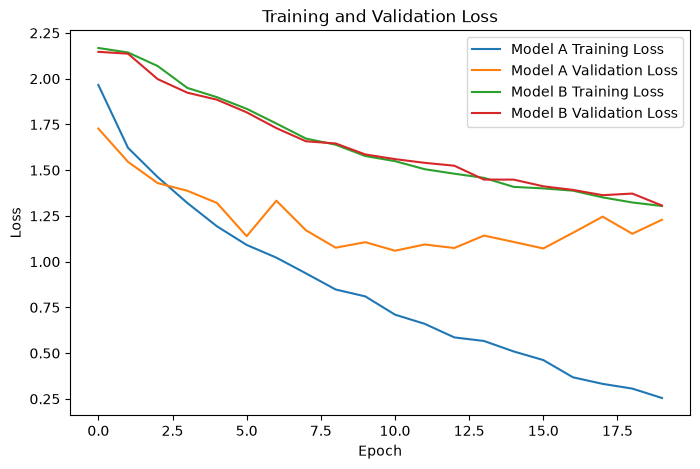

In [62]:
# Plots
plt.figure(figsize=(8, 5))

plt.plot(history_A.history["loss"], label="Model A Training Loss")
plt.plot(history_A.history["val_loss"], label="Model A Validation Loss")
plt.plot(history_B.history["loss"], label="Model B Training Loss")
plt.plot(history_B.history["val_loss"], label="Model B Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [63]:
# Evaluation on model A
test_loss_A, test_accuracy_A = model_A_final.evaluate(test_ds)
print("Model A Test Accuracy:", test_accuracy_A)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob_A = model_A_final.predict(test_ds)
y_pred_A = np.argmax(y_pred_prob_A, axis=1)
# confusion matrix
cm_A = confusion_matrix(y_true, y_pred_A)
print("Model A Confusion Matrix:")
print(cm_A)
#precision recall
precision_A = precision_score(y_true, y_pred_A, average="weighted")
recall_A = recall_score(y_true, y_pred_A, average="weighted")
print("Model A Precision:", precision_A)
print("Model A Recall:", recall_A)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.6087 - loss: 1.3450
Model A Test Accuracy: 0.6086956262588501
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Model A Confusion Matrix:
[[41  4  4  3  3  7  3  1  3]
 [ 1 53  0  1  4  0  0  0  3]
 [ 3  0 43  7  2  0  5  2  1]
 [ 4  5  4 80  5 10  5  5  0]
 [ 1  5  2 11 21  4 14 12  5]
 [ 5  1  4  7  1 47  6  4  0]
 [ 9  5  9 26  7  4 75  3  0]
 [ 0  0  0  8 10  1  2 27  0]
 [ 1 12  1  0  3  0  0  1 47]]
Model A Precision: 0.6093626928355421
Model A Recall: 0.6086956521739131


In [64]:
# Evaluation on model B
test_loss_B, test_accuracy_B = model_B_final.evaluate(test_ds)
print("Model B Test Accuracy:", test_accuracy_B)

y_pred_prob_B = model_B_final.predict(test_ds)
y_pred_B = np.argmax(y_pred_prob_B, axis=1)
# confusion matrix
cm_B = confusion_matrix(y_true, y_pred_B)
print("Model B Confusion Matrix:")
print(cm_B)
# precision recall
precision_B = precision_score(y_true, y_pred_B, average="weighted")
recall_B = recall_score(y_true, y_pred_B, average="weighted")
print("Model B Precision:", precision_B)
print("Model B Recall:", recall_B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5175 - loss: 1.3237
Model B Test Accuracy: 0.5175315737724304
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Model B Confusion Matrix:
[[39  3  5  4  0  6 10  1  1]
 [ 2 29  0  0  4  0 11  0 16]
 [ 8  1 33  3  7  0 10  1  0]
 [ 7  2  3 75  5  3 20  3  0]
 [ 7  2  1 20  7  1 28  2  7]
 [11  0  3 18  0 26 15  2  0]
 [10  1  3 13  7  4 93  6  1]
 [ 7  0  1 14  8  3  7  8  0]
 [ 0  5  0  0  1  0  0  0 59]]
Model B Precision: 0.5067790519576417
Model B Recall: 0.517531556802244


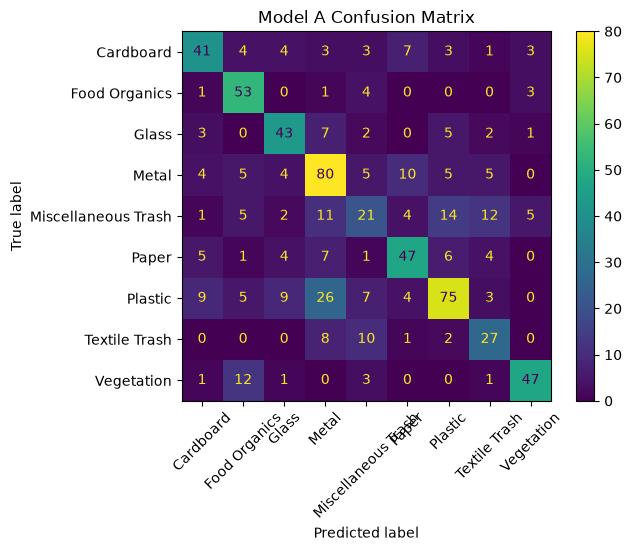

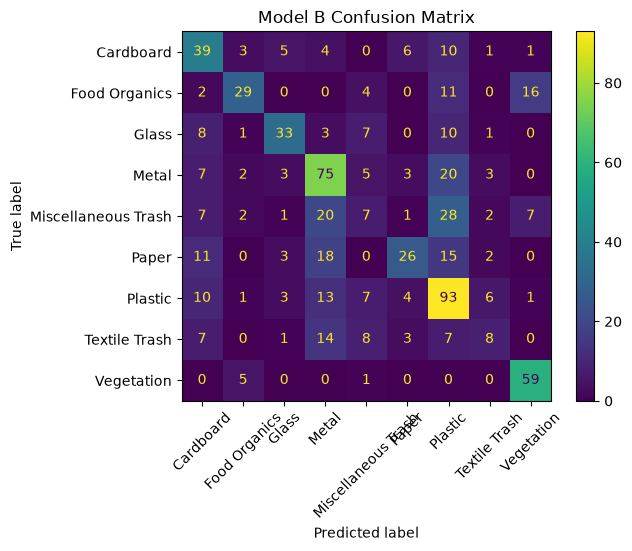

In [65]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_A,
    display_labels=class_names
).plot(xticks_rotation=45)

plt.title("Model A Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(
    confusion_matrix=cm_B,
    display_labels=class_names
).plot(xticks_rotation=45)

plt.title("Model B Confusion Matrix")
plt.show()

In [66]:
params_A = model_A_final.count_params()
params_B = model_B_final.count_params()

size_A_KB = params_A * 4 / 1024
size_B_KB = params_B * 4 / 1024

comparison_df = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "Total Parameters": [params_A, params_B],
    "Estimated Size (KB)": [size_A_KB, size_B_KB],
    "Training Time per Epoch (s)": [
        training_time_A / 20,
        training_time_B / 20
    ],
    "Test Accuracy": [
        test_accuracy_A,
        test_accuracy_B
    ]
})

comparison_df

,Model,Total Parameters,Estimated Size (KB),Training Time per Epoch (s),Test Accuracy
0,Model A,286377,1118.660156,7.649073,0.608696
1,Model B,5556,21.703125,7.020779,0.517532


### Compare with Lightweight State-of-the-Art Networks

#### SOTA Fine-Tuning & Evaluation

In [71]:
# MobileNetV2
mobilenet_v2=tf.keras.applications.MobileNetV2(input_shape=(64,64,3), include_top=False,weights="imagenet")
mobilenet_v2.trainable=True
model_mobilenet=models.Sequential([
    mobilenet_v2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES,activation="softmax")
])

model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
start_time = time.time()
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)
training_time_mobilenet = time.time() - start_time
print("MobileNetV2 total training time:", training_time_mobilenet)
print("MobileNetV2 time per epoch:", training_time_mobilenet / 20)

C:\Users\shala\AppData\Local\Temp\ipykernel_19036\647471357.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_v2=tf.keras.applications.MobileNetV2(input_shape=(64,64,3), include_top=False,weights="imagenet")


Epoch 1/20


c:\Users\shala\Desktop\Assignment 3 - PR\EN3150_Assignment03_CNN-1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.3608 - loss: 1.9289 - val_accuracy: 0.3001 - val_loss: 2.3837
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6197 - loss: 1.1250 - val_accuracy: 0.3857 - val_loss: 2.1983
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6909 - loss: 0.8911 - val_accuracy: 0.4264 - val_loss: 2.0409
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7697 - loss: 0.6674 - val_accuracy: 0.4306 - val_loss: 2.0651
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8319 - loss: 0.5005 - val_accuracy: 0.4698 - val_loss: 1.8762
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8605 - loss: 0.4165 - val_accuracy: 0.4993 - val_loss: 1.7954
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8867 - loss: 0.3470 - val_accuracy: 0.5231 - val_loss: 1.7325
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9173 - loss: 0.2699 - val_accuracy: 0.538

In [72]:
# EfficientNet-B0
efficientnet_b0 = tf.keras.applications.EfficientNetB0(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet"
)
efficientnet_b0.trainable = True
model_efficientnet = models.Sequential([
    efficientnet_b0,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_efficientnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
start_time = time.time()
history_efficientnet = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)
training_time_efficientnet = time.time() - start_time
print("EfficientNet-B0 total training time:", training_time_efficientnet)
print("EfficientNet-B0 time per epoch:", training_time_efficientnet / 20)

Epoch 1/20


c:\Users\shala\Desktop\Assignment 3 - PR\EN3150_Assignment03_CNN-1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.3226 - loss: 1.9066 - val_accuracy: 0.0884 - val_loss: 2.3131
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.5661 - loss: 1.2951 - val_accuracy: 0.0870 - val_loss: 2.4802
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.6569 - loss: 1.0047 - val_accuracy: 0.1206 - val_loss: 2.4722
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.7342 - loss: 0.8038 - val_accuracy: 0.1304 - val_loss: 2.3959
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7904 - loss: 0.6580 - val_accuracy: 0.1388 - val_loss: 2.4358
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8367 - loss: 0.5286 - val_accuracy: 0.2496 - val_loss: 2.3315
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8614 - loss: 0.4401 - val_accuracy: 0.3282 - val_loss: 2.0109
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8981 - loss: 0.3536 - val_accuracy: 0.253

In [73]:
# MobileNetV2
test_loss_mobilenet, test_accuracy_mobilenet = model_mobilenet.evaluate(test_ds)
# EfficientNet-B0
test_loss_efficientnet, test_accuracy_efficientnet = model_efficientnet.evaluate(test_ds)

# accuracy
print("MobileNetV2 Test Accuracy:", test_accuracy_mobilenet)
print("EfficientNet-B0 Test Accuracy:", test_accuracy_efficientnet)

# parameter count
params_mobilenet = model_mobilenet.count_params()
params_efficientnet = model_efficientnet.count_params()

print("MobileNetV2 parameters:", params_mobilenet)
print("EfficientNet-B0 parameters:", params_efficientnet)

# model size in MB
size_mobilenet_MB = params_mobilenet * 4 / (1024 ** 2)
size_efficientnet_MB = params_efficientnet * 4 / (1024 ** 2)

print("MobileNetV2 estimated size:", size_mobilenet_MB, "MB")
print("EfficientNet-B0 estimated size:", size_efficientnet_MB, "MB")

# create SOTA table
sota_comparison = pd.DataFrame({
    "Model": ["MobileNetV2", "EfficientNet-B0"],
    "Total Parameters": [params_mobilenet, params_efficientnet],
    "Model Size (MB)": [
        size_mobilenet_MB,
        size_efficientnet_MB
    ],
    "Test Accuracy": [
        test_accuracy_mobilenet,
        test_accuracy_efficientnet
    ]
})

sota_comparison

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 364ms/step - accuracy: 0.6620 - loss: 1.4974
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 483ms/step - accuracy: 0.4502 - loss: 1.8935
MobileNetV2 Test Accuracy: 0.6619915962219238
EfficientNet-B0 Test Accuracy: 0.4502103924751282
MobileNetV2 parameters: 2269513
EfficientNet-B0 parameters: 4061100
MobileNetV2 estimated size: 8.65750503540039 MB
EfficientNet-B0 estimated size: 15.491867065429688 MB


,Model,Total Parameters,Model Size (MB),Test Accuracy
0,MobileNetV2,2269513,8.657505,0.661992
1,EfficientNet-B0,4061100,15.491867,0.450210
